In [12]:
from collections import Counter, defaultdict
from pathlib import Path
import re
import matplotlib.pyplot as plt
import pandas as pd
import spacy
from HanTa import HanoverTagger as ht


ROOT = Path.cwd().resolve().parents[1]
TRANSCRIPT_DIR = ROOT / "podcast_data"
DEREWO_PATH = ROOT / "derewo-v-ww-bll-320000g-2012-12-31-1.0" / "derewo-v-ww-bll-320000g-2012-12-31-1.0.txt"
THRESHOLDS = [1000, 2000, 3000, 5000]
transcript_paths = sorted(TRANSCRIPT_DIR.rglob("*.txt"))


def expand_headword(headword):
    variants = set()
    for part in re.split(r",(?![^(]*\))", headword.lower()):
        part = part.strip()
        if not part:
            continue
        match = re.fullmatch(r"([^(]*)\(([^)]*)\)", part)
        if match:
            base, suffixes = match.group(1).strip(), match.group(2)
            if base:
                variants.add(base)
            for suffix in suffixes.split(","):
                suffix = suffix.strip()
                if suffix:
                    variants.add(base + suffix)
        else:
            variants.add(part)
    return variants


def load_derewo_rank_map(path):
    rank_map = {}
    rank = 0
    for line in path.read_text(encoding="latin1").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        rank += 1
        for variant in expand_headword(line.split()[0]):
            rank_map.setdefault(variant, rank)
    return rank_map

nlp = spacy.load("de_core_news_sm", disable=["parser", "ner"])
tagger = ht.HanoverTagger("morphmodel_ger.pgz")
lemma_rank = load_derewo_rank_map(DEREWO_PATH)

transcript_counters = {}
for path, doc in zip(
    transcript_paths,
    nlp.pipe([path.read_text(encoding="utf-8") for path in transcript_paths], batch_size=4),
):
    counter = Counter()
    for token in doc:
        if token.is_space or token.is_punct or token.like_num:
            continue

        lemma = (token.lemma_ or token.text).strip().lower()
        if not re.search(r"[^\W\d_]", lemma, re.UNICODE):
            continue

        if lemma not in lemma_rank:
            for suffix in ("r", "er"):
                if lemma.endswith(suffix):
                    candidate = lemma[: -len(suffix)]
                    if len(candidate) >= 3 and candidate in lemma_rank:
                        lemma = candidate
                        break

        if lemma not in lemma_rank:
            text = token.text.strip().lower()
            if re.fullmatch(r"[^\W\d_]+(?:-[^\W\d_]+)*", text, re.UNICODE):
                analysis = tagger.analyze(text)
                if analysis:
                    candidate = analysis[0] if isinstance(analysis, tuple) else analysis
                    candidate = candidate.strip().lower()
                    if candidate not in lemma_rank:
                        for suffix in ("r", "er"):
                            if candidate.endswith(suffix):
                                shortened = candidate[: -len(suffix)]
                                if len(shortened) >= 3 and shortened in lemma_rank:
                                    candidate = shortened
                                    break
                    if candidate in lemma_rank:
                        lemma = candidate

        counter[lemma] += 1

    transcript_counters[path] = counter

token_counter = Counter()
for counter in transcript_counters.values():
    token_counter.update(counter)

total_tokens = sum(token_counter.values())
off_list_tokens = sum(freq for lemma, freq in token_counter.items() if lemma not in lemma_rank)
coverage_rows = []
for threshold in THRESHOLDS:
    covered = sum(freq for lemma, freq in token_counter.items() if lemma_rank.get(lemma, float("inf")) <= threshold)
    coverage_rows.append((threshold, covered / total_tokens))

print(f"Total episodes: {len(transcript_paths)}")
print(f"Unique lemmas: {len(token_counter):,}")
print(f"Non-covered tokens: {off_list_tokens / total_tokens:.2%}")

print(f"{'threshold':<12} {'coverage':>10}")
for threshold, coverage in coverage_rows:
    print(f"top{threshold:>6,}   {coverage:>9.2%}")


Total episodes: 100
Unique lemmas: 39,525
Non-covered tokens: 4.68%
threshold      coverage
top 1,000      77.26%
top 2,000      81.90%
top 3,000      84.87%
top 5,000      87.59%


,podcast,tokens,unique_lemmas,off_list_%,top_1000
0,baywatch_berlin,139220,9747,4.48,79.22
1,edeltalk,116687,6361,4.72,78.30
2,forschergeist,136001,10056,3.67,78.24
3,zmethodisch_inkorrekt,188090,11073,4.55,77.83
4,klinisch_relevant_podcast,39200,4190,4.76,76.97
5,lage_der_nation,180022,12167,4.43,76.78
6,swr_kultur_lesenswert_-_literatur,29957,3417,5.73,76.35
7,ö1_radiokolleg,23358,3907,6.46,74.33
8,auf_der_spur_-_ard_ermittlerkrimis,54937,6122,6.02,72.76
9,alles_geschichte,35567,5368,7.01,71.90


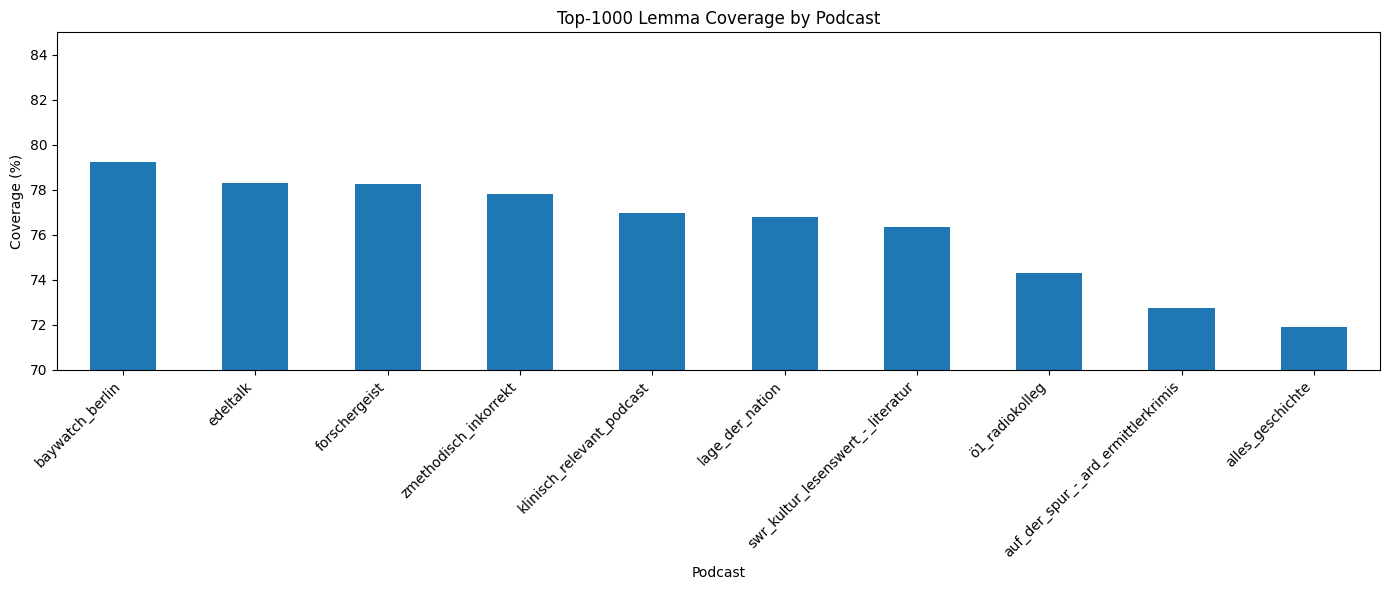

In [11]:
podcast_counters = defaultdict(Counter)

for path, counter in transcript_counters.items():
    podcast_counters[path.parent.name].update(counter)

rows = []
for podcast, counter in podcast_counters.items():
    total_tokens = sum(counter.values())
    off_list_tokens = sum(freq for lemma, freq in counter.items() if lemma not in lemma_rank)

    row = {
        "podcast": podcast,
        "tokens": total_tokens,
        "unique_lemmas": len(counter),
        "off_list_%": off_list_tokens / total_tokens * 100,
    }

    for threshold in THRESHOLDS:
        covered = sum(
            freq
            for lemma, freq in counter.items()
            if lemma_rank.get(lemma, float("inf")) <= threshold
        )
        row[f"top_{threshold}"] = covered / total_tokens * 100

    rows.append(row)

coverage_df = (
    pd.DataFrame(rows)
    .sort_values("top_1000", ascending=False)
    .reset_index(drop=True)
)

display(coverage_df[["podcast", "tokens", "unique_lemmas", "off_list_%", "top_1000"]].round(2))

plot_df = coverage_df.set_index("podcast")[["top_1000"]]
plot_df.plot(kind="bar", figsize=(14, 6), legend=False)
plt.ylabel("Coverage (%)")
plt.xlabel("Podcast")
plt.title("Top-1000 Lemma Coverage by Podcast")
plt.ylim(70, 85)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
